# EDA LOAN

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import style

import seaborn as sns

%matplotlib inline

In [ ]:
import warnings
warnings.filterwarnings("ignore")

style.use('ggplot') or plt.style.use('ggplot')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta = '/content/drive/MyDrive/ESPECIALISTA IA/data_loan.csv'

df_loan = pd.read_csv(ruta)

df_loan.sample(n=6)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Annual Income,Years in current job,Home Ownership,Number of Open Accounts,Number of Credit Problems,Bankruptcies
77767,576eb452-744d-423f-92df-236c5628c31f,b6c64db4-7c6b-4559-b026-64782daed04c,Fully Paid,129096.0,NaN,9 years,Rent,4.0,0.0,0.0
21407,b6645da0-256c-4d37-b605-080ff7907549,b3d90fbb-d18a-4283-880a-ab06c14e4f7f,Fully Paid,99999999.0,1224284.0,10+ years,Rent,9.0,0.0,0.0
6248,4b1485b0-560c-4341-ac78-c5c117969593,2256116e-07c6-42d1-ad6f-1c63cc9ef7fd,Fully Paid,66748.0,1366195.0,10+ years,Home Mortgage,12.0,1.0,1.0
25966,781d04fe-d4ce-43bb-ad7b-7a4519768ae5,28fb8647-0423-46f3-85f7-c247ab363ad9,Fully Paid,111628.0,964060.0,10+ years,Rent,8.0,0.0,0.0
96519,8db20234-ac9f-4065-b2c6-629a7786e1fe,8a7f716f-5ee0-4d4a-b793-2bd374475ac1,Fully Paid,134816.0,1164282.0,6 years,Home Mortgage,5.0,0.0,0.0
28841,8fab2baa-2548-4207-95e6-f289741bb9c2,02ebe684-aa4a-472e-8d56-b74026713a59,Fully Paid,398420.0,1720431.0,10+ years,Home Mortgage,11.0,0.0,0.0


In [ ]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Loan ID                    100000 non-null  object 
 1   Customer ID                100000 non-null  object 
 2   Loan Status                100000 non-null  object 
 3   Current Loan Amount        100000 non-null  float64
 4   Annual Income              80846 non-null   float64
 5   Years in current job       95778 non-null   object 
 6   Home Ownership             100000 non-null  object 
 7   Number of Open Accounts    100000 non-null  float64
 8   Number of Credit Problems  100000 non-null  float64
 9   Bankruptcies               99796 non-null   float64
dtypes: float64(5), object(5)
memory usage: 7.6+ MB


#### Eliminar campos ID por no necesarios

In [ ]:
df_loan.drop(columns=['Loan ID', 'Customer ID'], inplace=True)

df_loan.drop_duplicates(inplace=True)

#### Cambio nombre columnas (sin espacios)

In [ ]:
df_loan.columns = [columna.replace(' ','_') for columna in df_loan.columns.to_list()]

df_loan.columns

Index(['Loan_Status', 'Current_Loan_Amount', 'Annual_Income',
       'Years_in_current_job', 'Home_Ownership', 'Number_of_Open_Accounts',
       'Number_of_Credit_Problems', 'Bankruptcies'],
      dtype='object')

In [ ]:
df_loan.describe()

,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Number_of_Credit_Problems,Bankruptcies
count,8.975400e+04,7.062200e+04,89754.000000,89754.000000,89564.00000
mean,1.305642e+07,1.375883e+06,11.123482,0.165029,0.11556
std,3.329056e+07,1.104904e+06,4.999313,0.478075,0.34796
min,1.080200e+04,7.662700e+04,0.000000,0.000000,0.00000
25%,1.802680e+05,8.478845e+05,8.000000,0.000000,0.00000
50%,3.138740e+05,1.168908e+06,10.000000,0.000000,0.00000
75%,5.323670e+05,1.648915e+06,14.000000,0.000000,0.00000
max,1.000000e+08,1.655574e+08,76.000000,15.000000,7.00000


In [ ]:
df_loan.describe(include='object')

,Loan_Status,Years_in_current_job,Home_Ownership
count,89754,85953,89754
unique,2,11,4
top,Fully Paid,10+ years,Home Mortgage
freq,67117,27736,43530


### Separamos variables numéricas y categóricas

In [ ]:
var_num = df_loan.select_dtypes(exclude='object').columns.to_list()

var_cat = df_loan.select_dtypes(include='object').columns.to_list()


## ANALISIS UNIDIMENSIONAL

In [ ]:
# valores colormap
TABLEAU_CMP = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', \
               'tab:gray','tab:olive', 'tab:cyan')

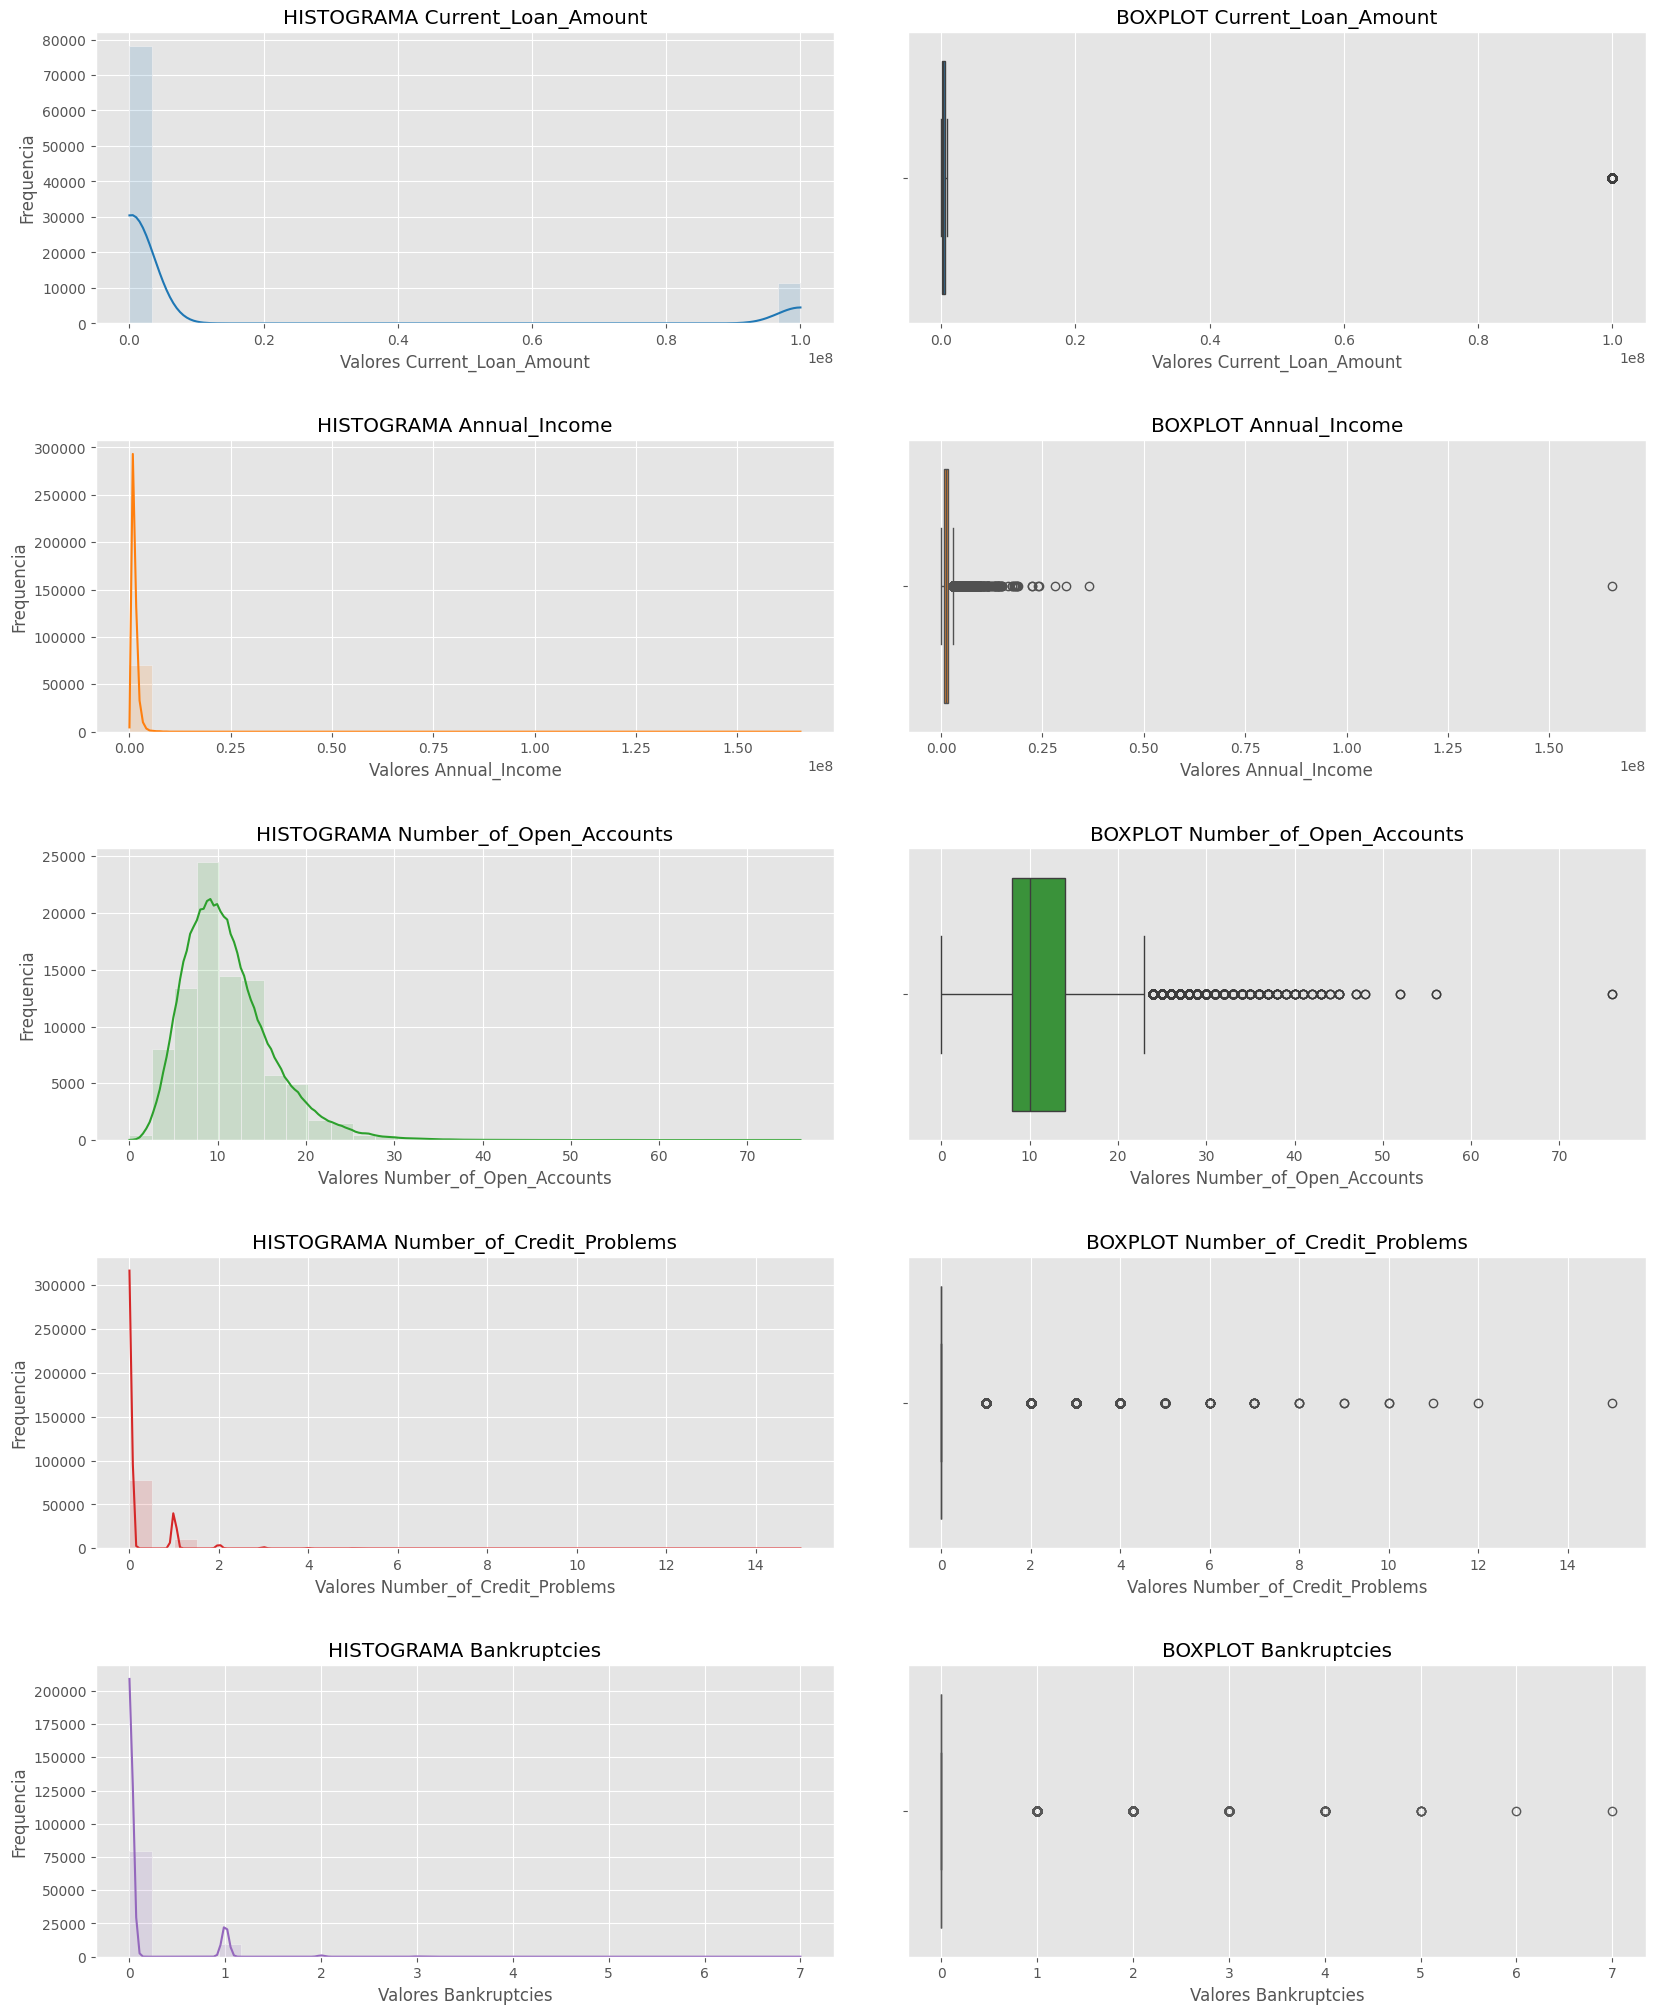

In [ ]:
# creamos la grafica
fig, axes = plt.subplots(len(var_num), 2, \
                         figsize=(20, 5 * len(var_num)), \
                         gridspec_kw={'hspace': 0.4, 'wspace': 0.1})
ax = axes.ravel()

# graficas distribucion y boxplot de cada atributo
for idx, atributo in enumerate(var_num):

    # distribucion (histograma)
    sns.histplot(df_loan[atributo], bins=30, ax=ax[2 * idx], \
                 color=TABLEAU_CMP[idx % len(TABLEAU_CMP)], alpha=0.15, kde=True)

    # titulo, etiquetas histograma
    ax[2 * idx].set_title(f'HISTOGRAMA {atributo}')
    ax[2 * idx].set_xlabel(f'Valores {atributo}')
    ax[2 * idx].set_ylabel("Frequencia")

    # boxplot
    sns.boxplot(x=atributo, data=df_loan, ax=ax[2 * idx + 1], color=TABLEAU_CMP[idx % len(TABLEAU_CMP)])

    # titulo, etiquetas boxplot
    ax[2 * idx + 1].set_title(f'BOXPLOT {atributo}')
    ax[2 * idx + 1].set_xlabel(f'Valores {atributo}')


# guardamos grafica:
fig.savefig('/content/drive/MyDrive/ESPECIALISTA IA/numericas')

##### Columna "cantidad credito", inspeccionar fila del único atípico. Mima cuestión para "Ingresos" y "Nº de cuentas, con el añadido de presencia de otros outliers + separados

## UNIDIMENSIONALES CATEGORICOS

In [ ]:
len(var_cat)

3

In [ ]:
var_cat

['Loan_Status', 'Years_in_current_job', 'Home_Ownership']

In [ ]:
colores = sns.color_palette("husl", len(var_cat))


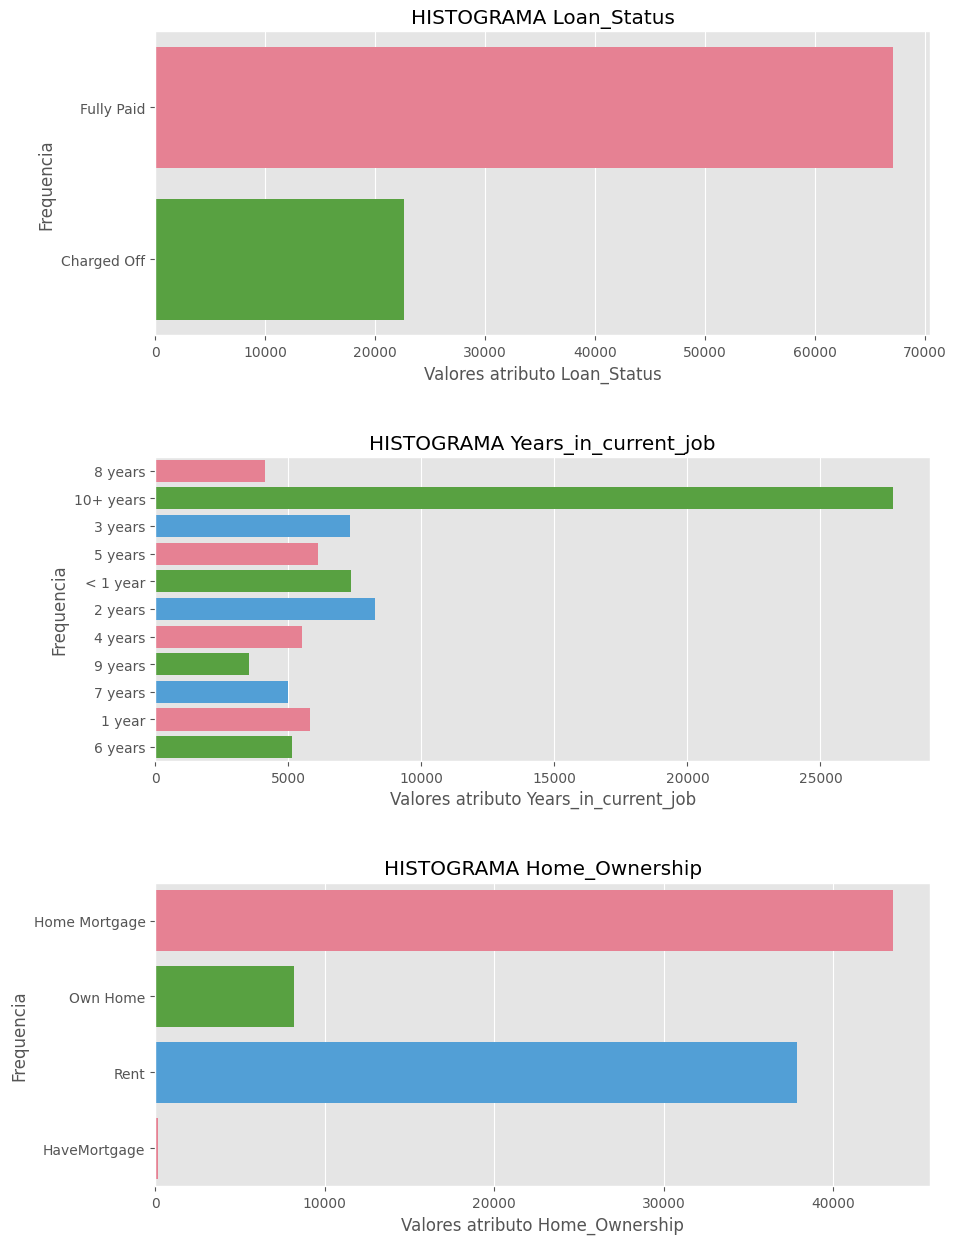

In [ ]:
# creacion graficas
fig, axes = plt.subplots(len(var_cat), 1, \
                         figsize=(10, 5*len(var_cat)),\
                         gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

ax = axes.ravel()

# dibujamos las graficas
for idx,variable in enumerate(var_cat):

    # utilizar el método de dibujo que nos interese en cada momento
    # sustituir nombre dataframe y parámetros según método de dibujo

    sns.countplot(df_loan[variable], ax=ax[idx],\
                  palette=colores)

    ax[idx].set_title(f'HISTOGRAMA {variable}')
    ax[idx].set_xlabel(f'Valores atributo {variable}')
    ax[idx].set_ylabel("Frequencia")



##### En esta última llevar a otra categoria o eliminar "haveMortgage"

### Primero categóricas Ver "Años trabajo" en mas detalle

In [ ]:
columna_anios_ordenada = df_loan.Years_in_current_job.sort_values()

columna_anios_ordenada

,Years_in_current_job
4581,1 year
34636,1 year
68875,1 year
84329,1 year
68884,1 year
...,...
99884,NaN
99895,NaN
99924,NaN
99963,NaN


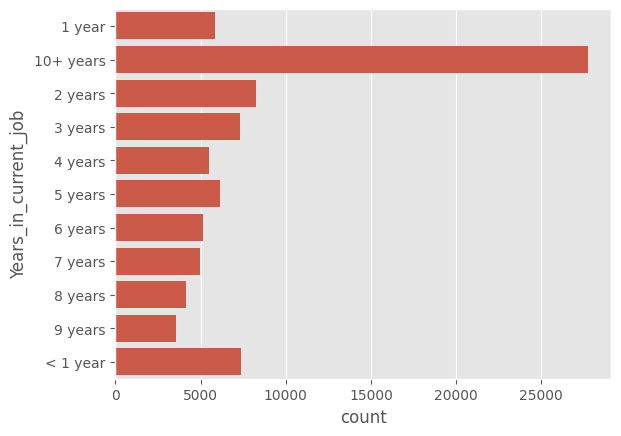

In [ ]:
sns.countplot(y=columna_anios_ordenada);

In [ ]:
df_loan.Years_in_current_job.unique()

array(['8 years', '10+ years', '3 years', '5 years', '< 1 year',
       '2 years', '4 years', '9 years', '7 years', '1 year', nan,
       '6 years'], dtype=object)

#### Vamos a reorganizar la categórica "Años de antiguedad":

In [ ]:
df_loan.Years_in_current_job.replace({'6 years': '6+ years', \
                                      '7 years': '6+ years', \
                                      '8 years': '6+ years', \
                                      '9 years': '6+ years'}).value_counts()


,count
Years_in_current_job,
10+ years,27736
6+ years,17786
2 years,8253
< 1 year,7365
3 years,7337
5 years,6136
1 year,5830
4 years,5510


La nueva categoria es demasiado alto el conteo, con lo cual una agrupacion de pequeños lo convierto en grande: **ERROR, falseo realidad.**

A partir de 6 años, esta vez voy a agrupar de 2 en 2

In [ ]:
df_loan.Years_in_current_job.replace({'6 years': '6_7 years', \
                                      '7 years': '6_7 years'}, \
                                    inplace=True)


In [ ]:
df_loan.Years_in_current_job.replace({'8 years': '8_9 years', \
                                      '9 years': '8_9 years'}, \
                                    inplace=True)

df_loan.Years_in_current_job.value_counts()


,count
Years_in_current_job,
10+ years,27736
6_7 years,10121
2 years,8253
8_9 years,7665
< 1 year,7365
3 years,7337
5 years,6136
1 year,5830
4 years,5510


- Procederiamos de la misma manera con el resto. De cualquier forma los intervalos que quedan estan mas cerca del mayor (10+) con lo cual no se falsearía la realidad.

In [ ]:
df_loan.Years_in_current_job.replace({'< 1 year': '<= 2 years', \
                                      '1 year': '<= 2 years', \
                                     '2 years': '<= 2 years'}, \
                                    inplace=True)


In [ ]:
df_loan.Years_in_current_job.replace({'3 years': '3_5 years', \
                                      '4 years': '3_5 years', \
                                      '5 years': '3_5 years'}, \
                                    inplace=True)


df_loan.Years_in_current_job.value_counts()


,count
Years_in_current_job,
10+ years,27736
<= 2 years,21448
3_5 years,18983
6_7 years,10121
8_9 years,7665


<Axes: xlabel='count', ylabel='Years_in_current_job'>

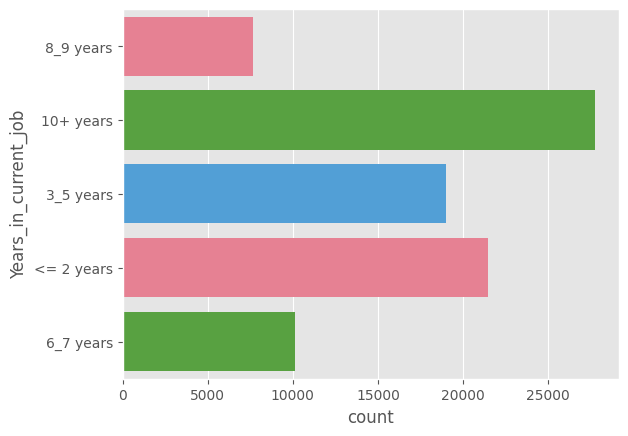

In [ ]:
sns.countplot(data=df_loan, y='Years_in_current_job',  palette=colores)

### Segundo categóricas: Categoria casi no apreciable categoria "HaveMortgage" en categórica "Home_Ownership"

In [ ]:
df_loan.Home_Ownership.value_counts()

,count
Home_Ownership,
Home Mortgage,43530
Rent,37843
Own Home,8198
HaveMortgage,183


In [ ]:
df_home_minoritario = df_loan[df_loan.Home_Ownership=='HaveMortgage']

len(df_home_minoritario)

183

**Comparamos distribuciones:**

In [ ]:
df_home_minoritario.describe()

,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Number_of_Credit_Problems,Bankruptcies
count,1.830000e+02,1.540000e+02,183.000000,183.000000,182.000000
mean,1.595667e+07,1.389022e+06,10.524590,0.191257,0.137363
std,3.657071e+07,7.317756e+05,4.462074,0.525744,0.345179
min,1.080200e+04,3.783660e+05,3.000000,0.000000,0.000000
25%,6.689100e+04,8.800040e+05,7.000000,0.000000,0.000000
50%,1.241680e+05,1.219610e+06,10.000000,0.000000,0.000000
75%,2.220680e+05,1.652948e+06,13.000000,0.000000,0.000000
max,1.000000e+08,4.340417e+06,24.000000,5.000000,1.000000


In [ ]:
df_loan.describe()

,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Number_of_Credit_Problems,Bankruptcies
count,8.975400e+04,7.062200e+04,89754.000000,89754.000000,89564.00000
mean,1.305642e+07,1.375883e+06,11.123482,0.165029,0.11556
std,3.329056e+07,1.104904e+06,4.999313,0.478075,0.34796
min,1.080200e+04,7.662700e+04,0.000000,0.000000,0.00000
25%,1.802680e+05,8.478845e+05,8.000000,0.000000,0.00000
50%,3.138740e+05,1.168908e+06,10.000000,0.000000,0.00000
75%,5.323670e+05,1.648915e+06,14.000000,0.000000,0.00000
max,1.000000e+08,1.655574e+08,76.000000,15.000000,7.00000


Alguna diferencia mínima, acaso estariamos eliminando de outliers. Veamos el target:

In [ ]:
df_home_minoritario.Loan_Status.value_counts()

,count
Loan_Status,
Fully Paid,152
Charged Off,31


De nuevo mayoritaria "Fully Paid" y separada.
#### Nos queda eliminar las filas de la categoria minima en "Home_Ownership" (también válido reagrupar):

<Axes: xlabel='count', ylabel='Home_Ownership'>

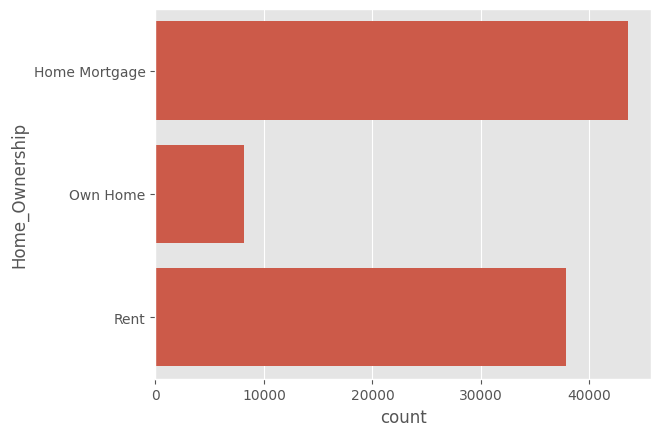

In [ ]:
idx = df_loan[df_loan.Home_Ownership=='HaveMortgage'].index
df_loan = df_loan.drop(index=idx)

sns.countplot(df_loan.Home_Ownership)

In [ ]:
len(df_loan)

89571

## ANÁLISIS BIDIMENSIONAL

### Categórico-categorico.

In [ ]:
var_cat

['Loan_Status', 'Years_in_current_job', 'Home_Ownership']

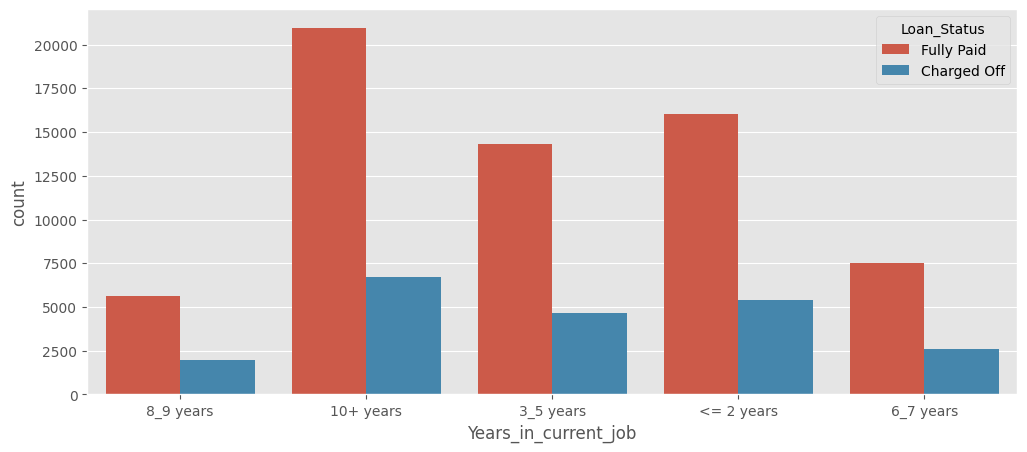

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))

sns.countplot(x='Years_in_current_job', hue='Loan_Status', \
              data=df_loan);

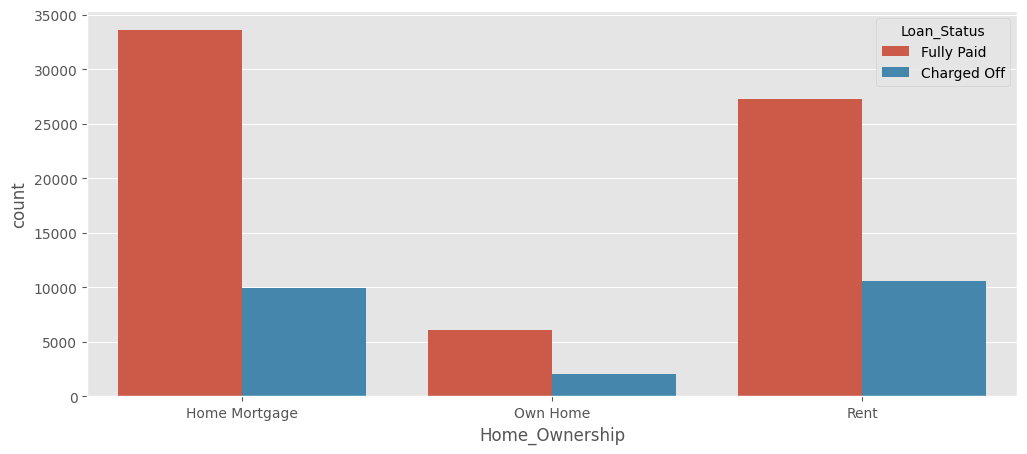

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))

sns.countplot(x='Home_Ownership', hue='Loan_Status', \
              data=df_loan);

- No sabemos si el cambio entre "Home Mortage" y "Rent" es significativo o se debe solo a la aleatoridad. Nos ayudamos de la siguiente gráfica (entre las apiladas, la de frecuencia 1):

<Axes: xlabel='Home_Ownership', ylabel='Count'>

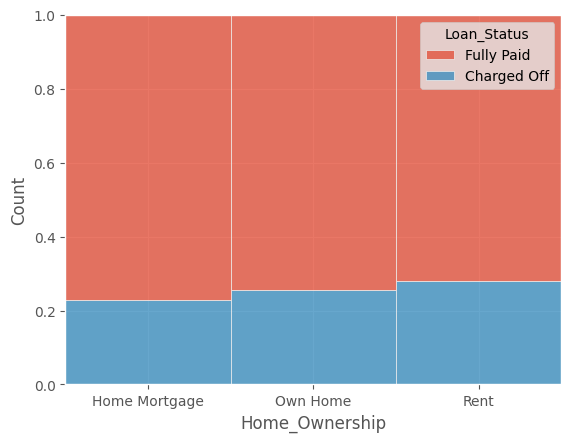

In [ ]:
sns.histplot(data=df_loan, x="Home_Ownership", hue="Loan_Status", multiple="fill")

Como vemos no hay diferencias significantes en las proporciones del target para cada valor, por lo cual **NO PODEMOS AFRIMAR QUE HOME_OWNERSHIP INFLUYE EN EL TARGET**

RESUMEN: **"antiguedad trabajo" no tendria influencia en el target, tampoco "Home Ownership".** No se toma ninguna acción.

### Numérico-numérico.

Primero vistazo general con "pairplot":

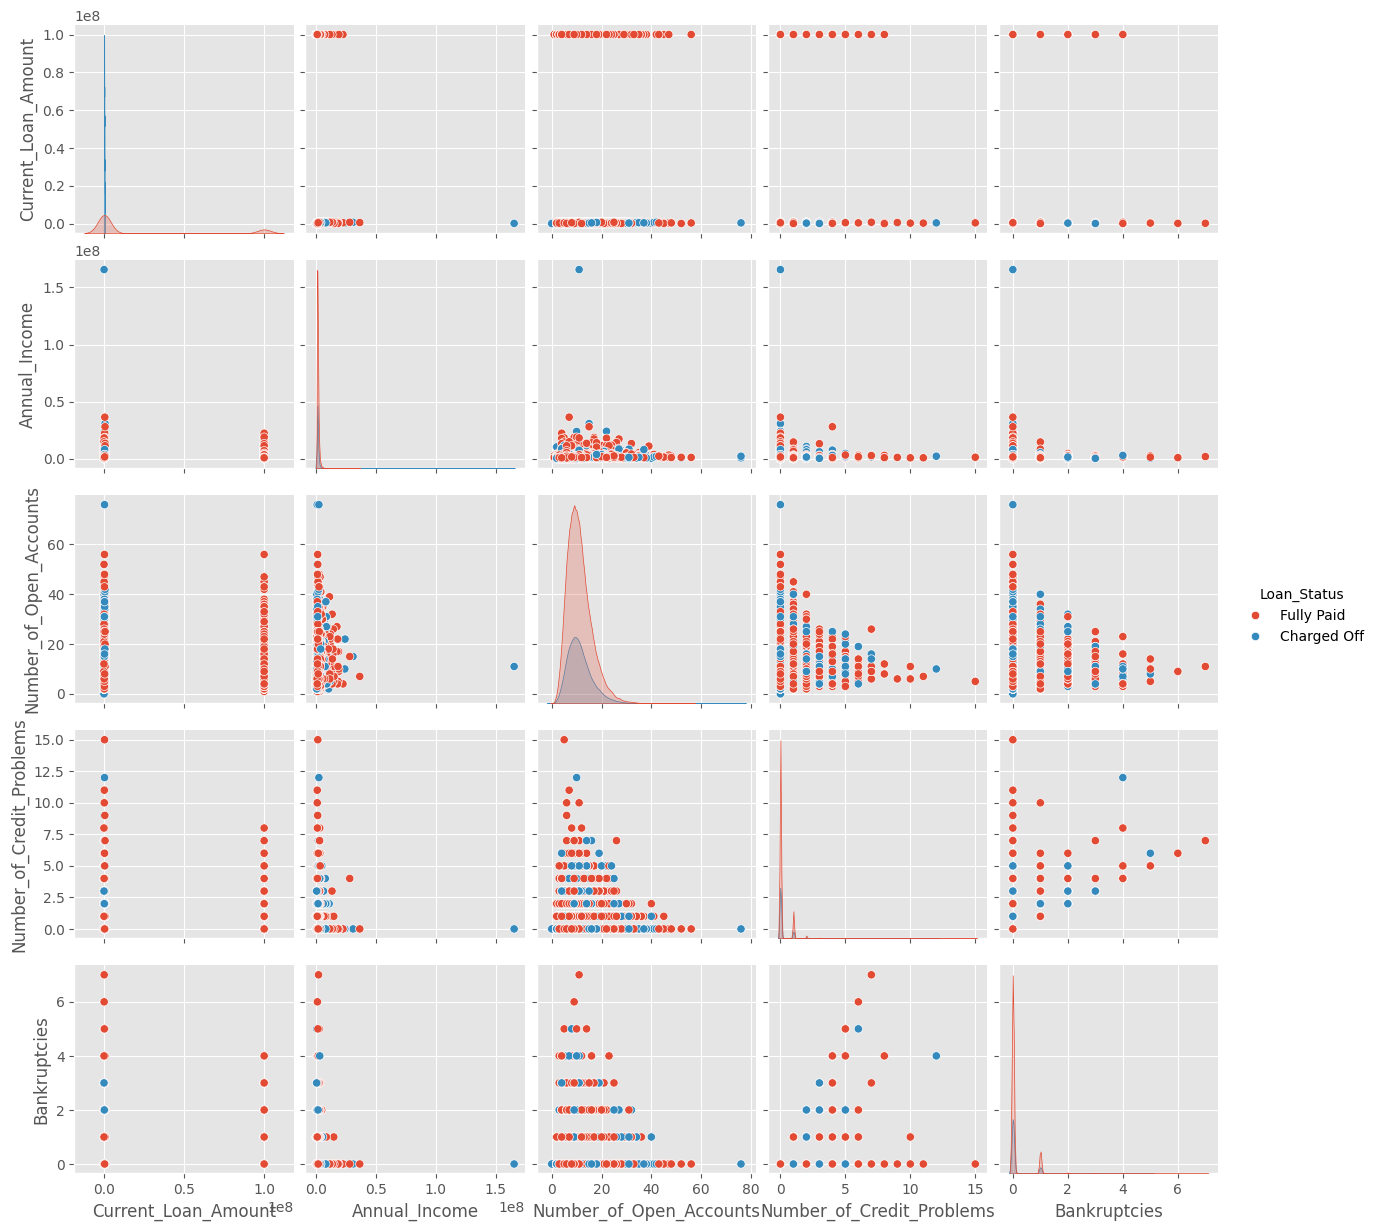

In [ ]:
sns.pairplot(data=df_loan, diag_kind='kde',hue='Loan_Status');

In [ ]:
# recuerden 'numeric_only=True'
mat_corr = df_loan.corr(numeric_only=True)

mat_corr


,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Number_of_Credit_Problems,Bankruptcies
Current_Loan_Amount,1.000000,0.014649,0.002057,-0.000183,0.001908
Annual_Income,0.014649,1.000000,0.142306,-0.016472,-0.046825
Number_of_Open_Accounts,0.002057,0.142306,1.000000,-0.015325,-0.025677
Number_of_Credit_Problems,-0.000183,-0.016472,-0.015325,1.000000,0.753139
Bankruptcies,0.001908,-0.046825,-0.025677,0.753139,1.000000


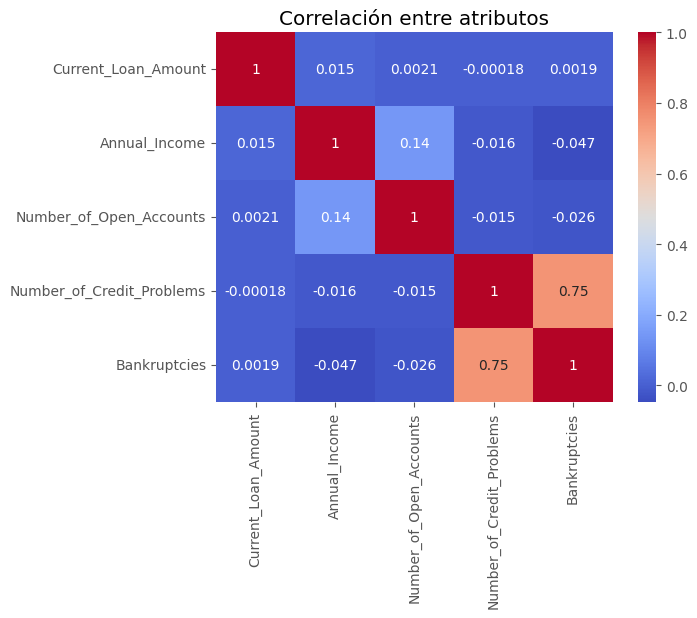

In [ ]:
sns.heatmap(mat_corr, annot=True, cbar=True, \
            cmap=sns.color_palette("coolwarm", as_cmap=True))
plt.title('Correlación entre atributos');

- **Eliminariamos una de las dos, la que tuviera menos influencia en el target.**

### Numérico-categorico.

In [ ]:
var_num

['Current_Loan_Amount',
 'Annual_Income',
 'Number_of_Open_Accounts',
 'Number_of_Credit_Problems',
 'Bankruptcies']

In [ ]:
var_cat

['Loan_Status', 'Years_in_current_job', 'Home_Ownership']

In [ ]:
df_loan.columns

Index(['Loan_Status', 'Current_Loan_Amount', 'Annual_Income',
       'Years_in_current_job', 'Home_Ownership', 'Number_of_Open_Accounts',
       'Number_of_Credit_Problems', 'Bankruptcies'],
      dtype='object')

- Vamos a aprovechar y estudiamos las dos correladas respecto al target:

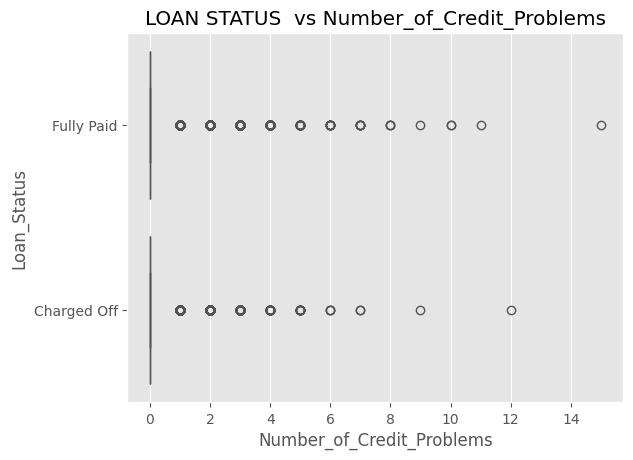

In [ ]:
sns.boxplot(data=df_loan, x='Number_of_Credit_Problems', y='Loan_Status')

plt.title('LOAN STATUS  vs Number_of_Credit_Problems');

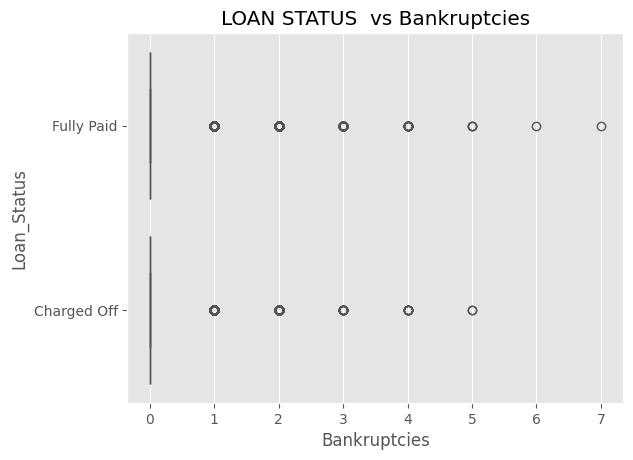

In [ ]:
sns.boxplot(data=df_loan, x='Bankruptcies', y='Loan_Status')

plt.title('LOAN STATUS  vs Bankruptcies');

- Dada la naturaleza de ambas (númerica ENTERA con valores distintos relativamente bajos y pocos) no podemos afirmar por las gráficas que tengan influencia con el target, con lo cual y siendo correladas eliminamos una cualquiera:

In [ ]:
df_loan.drop(columns='Number_of_Credit_Problems', inplace=True)

df_loan.columns

Index(['Loan_Status', 'Current_Loan_Amount', 'Annual_Income',
       'Years_in_current_job', 'Home_Ownership', 'Number_of_Open_Accounts',
       'Bankruptcies'],
      dtype='object')

## OUTLIERS

In [ ]:
# valores colormap
TABLEAU_CMP = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', \
               'tab:gray','tab:olive', 'tab:cyan')

In [ ]:
var_num.remove('Number_of_Credit_Problems')

In [ ]:
var_num

['Current_Loan_Amount',
 'Annual_Income',
 'Number_of_Open_Accounts',
 'Bankruptcies']

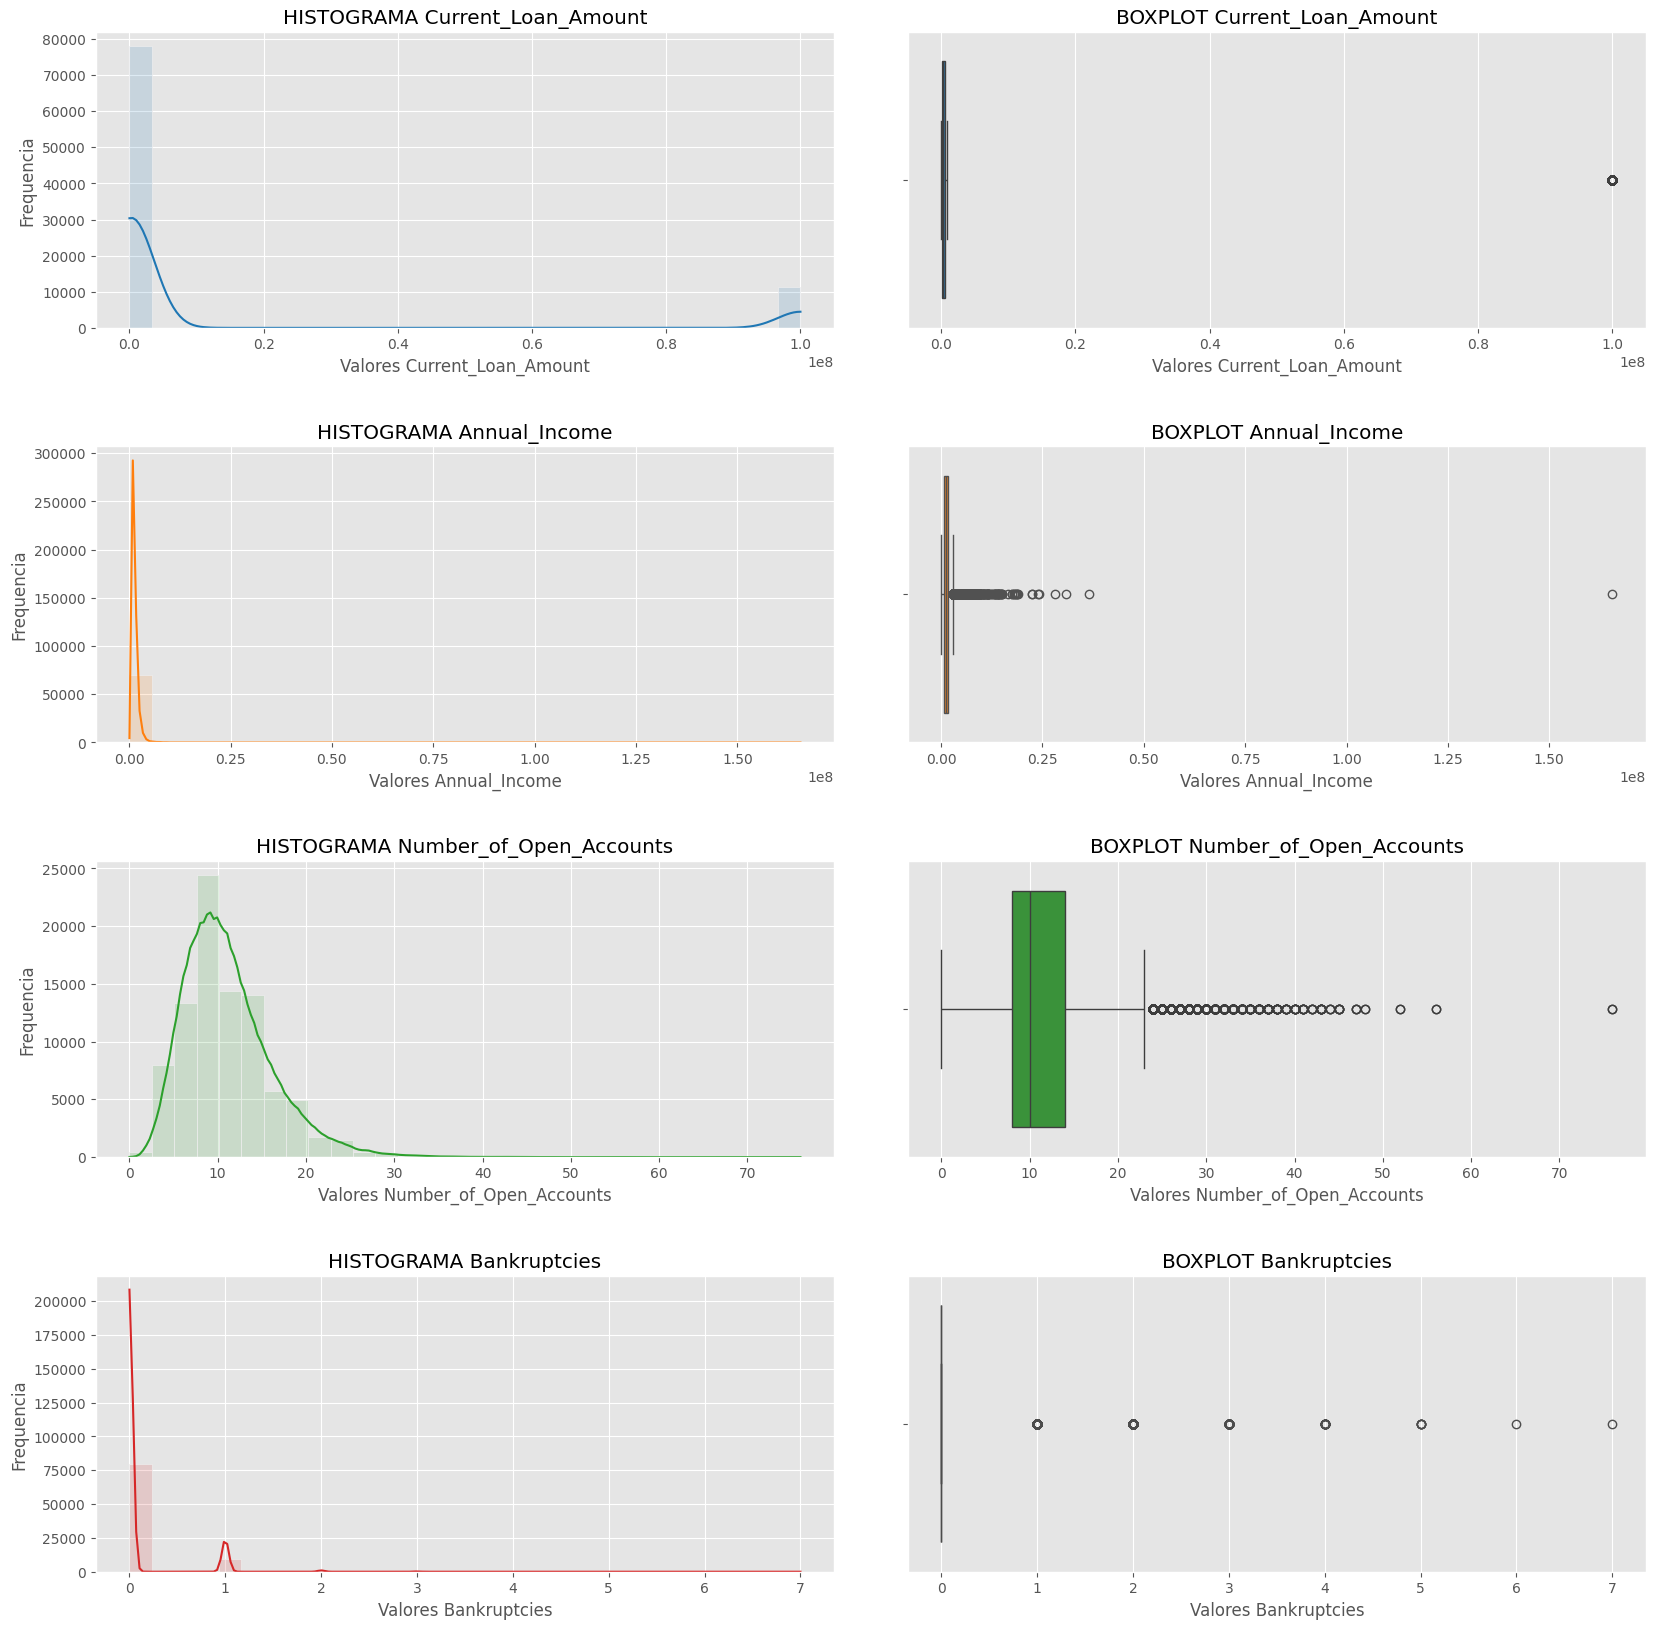

In [ ]:
# creamos la grafica
fig, axes = plt.subplots(len(var_num), 2, \
                         figsize=(20, 5 * len(var_num)), \
                         gridspec_kw={'hspace': 0.4, 'wspace': 0.1})
ax = axes.ravel()

# graficas distribucion y boxplot de cada atributo
for idx, atributo in enumerate(var_num):

    # distribucion (histograma)
    sns.histplot(x=atributo, data=df_loan, bins=30, ax=ax[2 * idx], \
                 color=TABLEAU_CMP[idx % len(TABLEAU_CMP)], alpha=0.15, kde=True)

    # titulo, etiquetas histograma
    ax[2 * idx].set_title(f'HISTOGRAMA {atributo}')
    ax[2 * idx].set_xlabel(f'Valores {atributo}')
    ax[2 * idx].set_ylabel("Frequencia")

    # boxplot
    sns.boxplot(x=atributo, data=df_loan, ax=ax[2 * idx + 1], color=TABLEAU_CMP[idx % len(TABLEAU_CMP)])

    # titulo, etiquetas boxplot
    ax[2 * idx + 1].set_title(f'BOXPLOT {atributo}')
    ax[2 * idx + 1].set_xlabel(f'Valores {atributo}')


# guardamos grafica:
fig.savefig('numericas')

#### Recuperamos el valor mas extremo de Current Loan. ¿Coincidirá con los mas extremos de las dos columnas siguientes en la matriz de graficas?


In [ ]:
df_loan[df_loan.Current_Loan_Amount>0.8e8]

,Loan_Status,Current_Loan_Amount,Annual_Income,Years_in_current_job,Home_Ownership,Number_of_Open_Accounts,Bankruptcies
2,Fully Paid,99999999.0,2231892.0,8_9 years,Own Home,18.0,0.0
10,Fully Paid,99999999.0,714628.0,3_5 years,Rent,16.0,0.0
12,Fully Paid,99999999.0,776188.0,<= 2 years,Own Home,6.0,0.0
13,Fully Paid,99999999.0,1560907.0,3_5 years,Rent,10.0,1.0
26,Fully Paid,99999999.0,1029857.0,<= 2 years,Rent,6.0,0.0
...,...,...,...,...,...,...,...
99970,Fully Paid,99999999.0,1058376.0,<= 2 years,Home Mortgage,12.0,0.0
99971,Fully Paid,99999999.0,1530564.0,8_9 years,Rent,10.0,0.0
99990,Fully Paid,99999999.0,1190046.0,<= 2 years,Rent,9.0,0.0
99996,Fully Paid,99999999.0,1289416.0,<= 2 years,Rent,22.0,0.0


In [ ]:
df_loan[df_loan.Current_Loan_Amount>0.8e8].describe()

,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Bankruptcies
count,11447.0,1.144700e+04,11447.000000,11420.000000
mean,99999999.0,1.408917e+06,11.138901,0.117688
std,0.0,9.339810e+05,5.047469,0.350875
min,99999999.0,9.486700e+04,1.000000,0.000000
25%,99999999.0,8.670745e+05,8.000000,0.000000
50%,99999999.0,1.215487e+06,10.000000,0.000000
75%,99999999.0,1.698714e+06,14.000000,0.000000
max,99999999.0,2.244888e+07,56.000000,4.000000


In [ ]:
df_loan[df_loan.Current_Loan_Amount>0.8e8].describe(include='object')

,Loan_Status,Years_in_current_job,Home_Ownership
count,11447,11020,11447
unique,1,5,3
top,Fully Paid,10+ years,Home Mortgage
freq,11447,3563,5717


### Los datos son claramente erroneos, no podemos conservarlos, los eliminamos

In [ ]:
idx_mas_extremo = df_loan[df_loan.Current_Loan_Amount>0.8e8].index

# auxiliar para comparar antes y despues
df_loan_con_outl = df_loan.copy()

df_loan.drop(index=idx_mas_extremo, inplace=True)


<Axes: xlabel='count', ylabel='Loan_Status'>

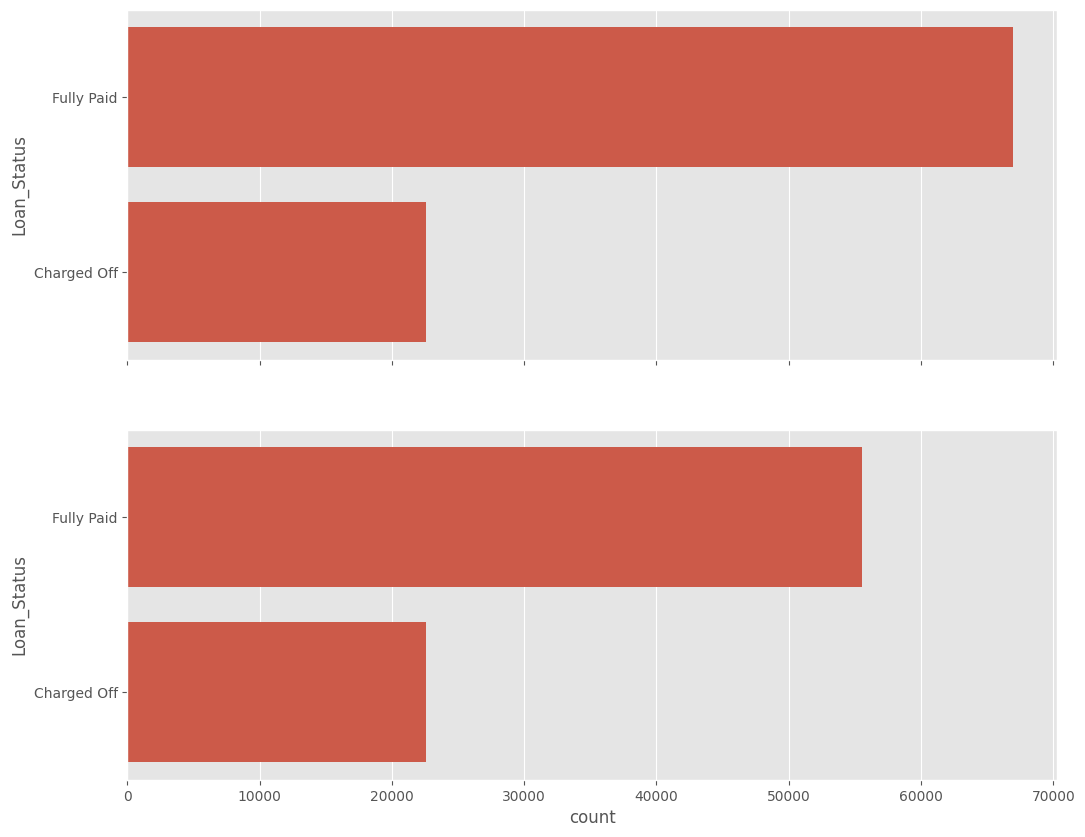

In [ ]:
# COMPARAR TARGET ANTES Y DESPUES (aunque no teniamos otra que eliminar)

fig, axes = plt.subplots(2,1,figsize=(12,10), sharex=True)

sns.countplot(y=df_loan_con_outl.Loan_Status, ax=axes[0])

sns.countplot(y=df_loan.Loan_Status, ax=axes[1])






### Ingresos Anuales: valor muy separado + otros extremos

Recuperamos el valor separado (por encima de 1.50e8 en la gráfica)

In [ ]:
df_loan[df_loan.Annual_Income>1.50e8]

,Loan_Status,Current_Loan_Amount,Annual_Income,Years_in_current_job,Home_Ownership,Number_of_Open_Accounts,Bankruptcies
85662,Charged Off,176132.0,165557393.0,10+ years,Home Mortgage,11.0,0.0


#### Valor muy separado, una unica fila lo eliminamos

In [ ]:
idx_mas_extremo_Income = df_loan[df_loan.Annual_Income>1.50e8].index

df_loan_con_outl = df_loan.copy()


df_loan.drop(index=idx_mas_extremo_Income, inplace=True)

<Axes: xlabel='Annual_Income'>

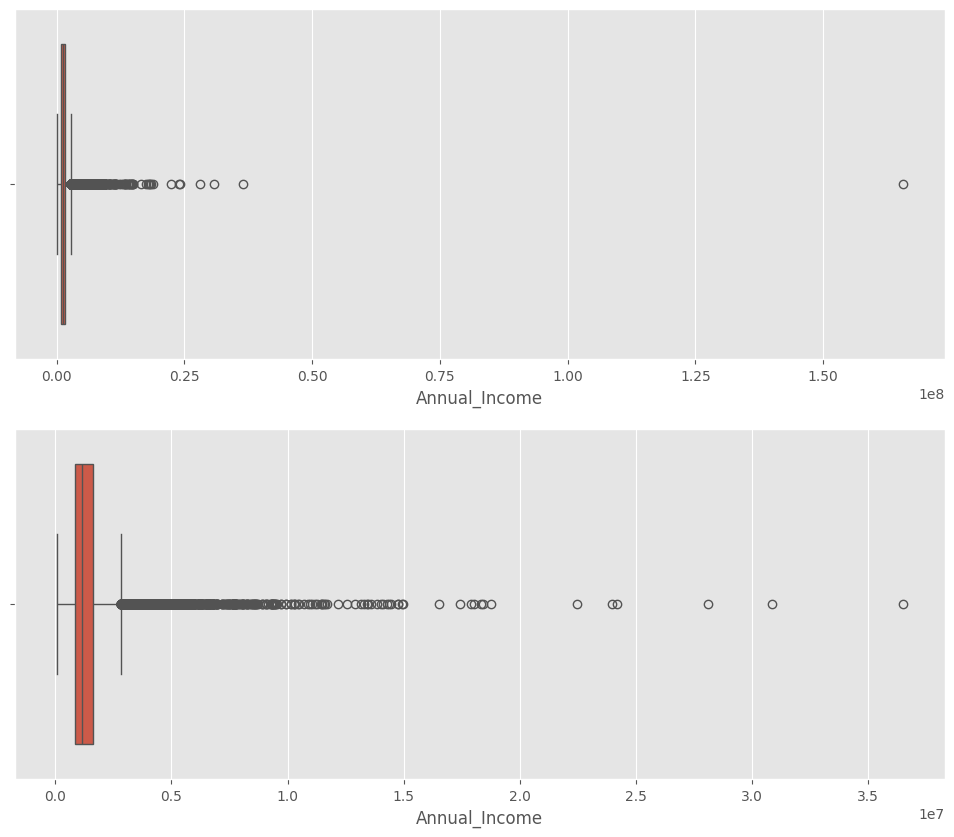

In [ ]:
# COMPARAR COLUMNA ANTES Y DESPUES

fig, axes = plt.subplots(2,1,figsize=(12,10))

sns.boxplot(x='Annual_Income', data=df_loan_con_outl, ax=axes[0])

sns.boxplot(x='Annual_Income', data=df_loan, ax=axes[1])




No parece que todos los outliers se puedan señalar como posibles errores. **Una de las opciones que no hemos tratado es la de truncar**. En la **gráfica** vemos que **los outliers hasta 1.5e7 estanmas cerca unos de otros, y parece en mayor nº. Pudieramos pensar en recortar la columna hasta este valor**. Analizamos:



### ¿Cuantos son los que estan por arriba de 1.5e7 en "Income"? ¿Son pocos? ¿cual es la distribución de las variables para ese conjunto?

In [ ]:
len(df_loan[df_loan.Annual_Income>1.5e7])

13

UN vistazito, pero son muy pocos:

In [ ]:
df_loan[df_loan.Annual_Income>1.5e7].describe()

,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Bankruptcies
count,13.000000,1.300000e+01,13.000000,13.0
mean,556393.538462,2.240930e+07,12.461538,0.0
std,229459.629912,6.139551e+06,7.400624,0.0
min,215314.000000,1.650530e+07,4.000000,0.0
25%,350416.000000,1.803324e+07,7.000000,0.0
50%,622402.000000,1.876820e+07,11.000000,0.0
75%,759066.000000,2.416154e+07,15.000000,0.0
max,786940.000000,3.647544e+07,27.000000,0.0


In [ ]:
df_loan[df_loan.Annual_Income>1.5e7].describe(include='object')

,Loan_Status,Years_in_current_job,Home_Ownership
count,13,13,13
unique,2,5,3
top,Fully Paid,10+ years,Home Mortgage
freq,10,6,5


### Veamos el segundo grupo de outliers. Para ello tenemos que hacer algún cálculo:

Calculamos el limite máximo superior admisible:

In [ ]:
Q1, Q3 = df_loan.Annual_Income.quantile([0.25,0.75])

IQR = Q3 - Q1

lim_superior = Q3 + 1.5*IQR

print('Cuartiles: ', Q1, Q3)
print('IQR: ',IQR)
print('Limite superior: ', lim_superior)

Cuartiles:  844322.0 1640217.75
IQR:  795895.75
Limite superior:  2834061.375


In [ ]:
# cuantos estan en este intervalo?
len(df_loan[(df_loan.Annual_Income>lim_superior) & (df_loan.Annual_Income<1.5e7)])

2783

In [ ]:
df_loan[(df_loan.Annual_Income>lim_superior) & (df_loan.Annual_Income<1.5e7)].describe()

,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Bankruptcies
count,2783.000000,2.783000e+03,2783.000000,2774.000000
mean,505303.011858,3.979914e+06,12.931369,0.058760
std,213171.467998,1.554919e+06,5.644064,0.259977
min,28358.000000,2.834325e+06,2.000000,0.000000
25%,335412.000000,3.069488e+06,9.000000,0.000000
50%,529166.000000,3.459330e+06,12.000000,0.000000
75%,702097.000000,4.226056e+06,16.000000,0.000000
max,789250.000000,1.497561e+07,47.000000,4.000000


In [ ]:
df_loan[(df_loan.Annual_Income>lim_superior) & (df_loan.Annual_Income<1.5e7)].describe(include='object')

,Loan_Status,Years_in_current_job,Home_Ownership
count,2783,2765,2783
unique,2,5,3
top,Fully Paid,10+ years,Home Mortgage
freq,2183,959,1947


In [ ]:
2800/len(df_loan)

0.035840917527488705

#### Si optaramos por recortar en 1.5e7

In [ ]:
df_con_outl2_AnnualIncome = df_loan.copy()

df_loan.Annual_Income = np.where(df_loan.Annual_Income > 1.5e7, 1.5e7, df_loan.Annual_Income)



<Axes: xlabel='Annual_Income'>

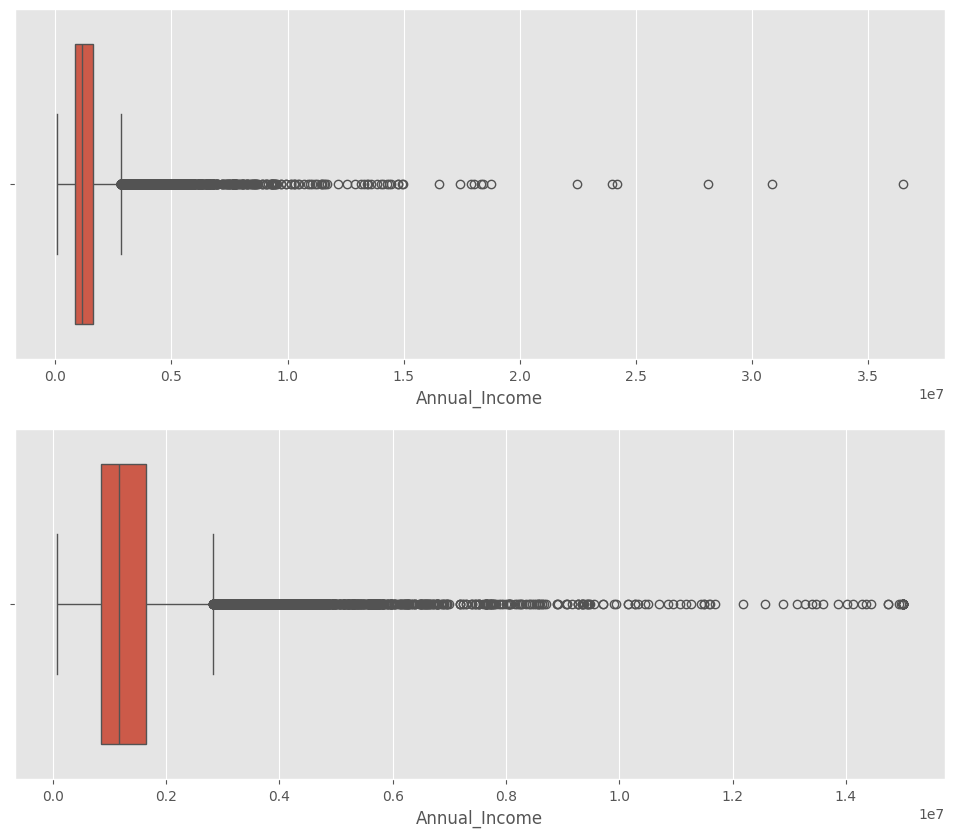

In [ ]:
# COMPARAR COLUMNA ANTES Y DESPUES

fig, axes = plt.subplots(2,1,figsize=(12,10))

sns.boxplot(x='Annual_Income', data=df_con_outl2_AnnualIncome, ax=axes[0])

sns.boxplot(x='Annual_Income', data=df_loan, ax=axes[1])

#### Con esto decidimos no eliminar los valores superiores a 1.5e7, y que esos valores al menos aporten al valor recortado.

Recordar que esta opción seria la última a utilizar.